# Email Spam Detection using NLP & Machine Learning

This project builds a machine learning model to classify text messages as **Spam** or **Ham** using Natural Language Processing (NLP).

### Technologies Used
- Python
- Pandas
- NumPy
- NLTK
- Scikit-learn
- Matplotlib
- Seaborn
- WordCloud

### Machine Learning Models
- Multinomial Naive Bayes
- Logistic Regression

## Project Overview

The objective of this project is to develop a binary text classification system that can automatically identify spam messages.

The project covers:

1. Dataset loading and exploration
2. Class distribution analysis
3. Text preprocessing
4. TF-IDF feature extraction
5. Train/test splitting
6. Multinomial Naive Bayes classification
7. Logistic Regression classification
8. Model evaluation
9. Confusion matrix analysis
10. WordCloud visualization
11. Testing predictions on new messages

## 1. Import Libraries

In [6]:
%pip install pandas

   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/10.0 MB 1.5 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/10.0 MB 1.6 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/10.0 MB 1.9 MB/s eta 0:00:05
   ------ --------------------------------- 1.6/10.0 MB 1.8 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/10.0 MB 1.9 MB/s eta 0:00:05
   ----------- ---------------------------- 2.9/10.0 MB 2.1 MB/s eta 0:00:04
   ------------- -------------------------- 3.4/10.0 MB 2.3 MB/s eta 0:00:03
   ----------------- ---------------------- 4.5/10.0 MB 2.6 MB/s eta 0:00:03
   ---------------------- ----------------- 5.5/10.0 MB 2.9 MB/s eta 0:00:02
   -------------------------- ------------- 6.6/10.0 MB 3.1 MB/s eta 0:00:02
   ------------------------------ --------- 7.6/10.0 MB 3.3 MB/s eta 0:00:01
   ----------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
%pip install numpy pandas scikit-learn nltk matplotlib seaborn wordcloud

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.4 MB 785.8 kB/s eta 0:00:10
   -- ------------------------------------- 0.5/8.4 MB 785.8 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/8.4 MB 892.8 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/8.4 MB 892.8 kB/s eta 0:00:09
   ----- ---------------------------------- 1.0/8.4 MB 718.6 kB/s eta 0:00:11
   ----- ---------------------------------- 1.0/8.4 MB 718.6 kB/s eta 0:00:11
   ------ --------------------------------- 1.3/8.4 MB 681.5 kB/s eta 0:00:11
   ------ --------------------------------- 1.3/

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import pandas as pd
import numpy as np
import sklearn
import nltk
import matplotlib
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load Dataset

In [10]:
import pandas as pd

df = pd.read_csv(
    "../data/spam.csv",
    encoding="latin1"
)

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## 3. Data Understanding

In [11]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (5572, 5)
Columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


## 4. Class Distribution
Step 4 — Understand and Clean the Dataset

We'll do this carefully and one step at a time.

4.1 Check the dataset

In [12]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [14]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

4.2 Remove unnecessary columns

If your dataset still has these columns:
v1
v2
Unnamed: 2
Unnamed: 3
Unnamed: 4

In [15]:
df = df[['v1', 'v2']]

In [16]:
df = df.rename(columns={
    'v1': 'label',
    'v2': 'message'
})

In [17]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


4.3 Check duplicate messages

In [18]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 403


In [19]:
df = df.drop_duplicates()

In [20]:
print("Dataset shape:", df.shape)

Dataset shape: (5169, 2)


4.4 Check Spam vs Ham

In [21]:
df['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

In [22]:
df['label'].value_counts(normalize=True) * 100

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

4.5 Create your first visualization

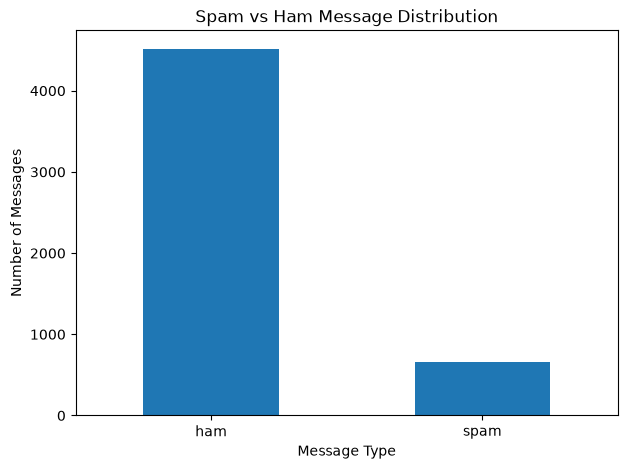

In [23]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Spam vs Ham Message Distribution')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')
plt.xticks(rotation=0)
plt.show()

Step 5 — Text Preprocessing

Our messages contain things like:

"Congratulations!!! You have WON £1000!!!"

Machine-learning models work better when we clean the text.

We'll perform:

Lowercase conversion
Punctuation removal
Number removal
Stopword removal
Extra-space removal

We will not use stemming/lemmatization yet because it isn't necessary for this dataset.

5.1 Import required libraries

In [24]:
import re
import string
import nltk

from nltk.corpus import stopwords

5.2 Download English stopwords

In [25]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mohan\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

5.3 Create the stopword list

In [26]:
stop_words = set(stopwords.words('english'))

print("Number of stopwords:", len(stop_words))

Number of stopwords: 198


5.4 Create our text-cleaning function

In [27]:
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Split text into words
    words = text.split()
    
    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]
    
    # Join words back together
    text = ' '.join(words)
    
    return text

5.5 Test the function

In [28]:
sample_text = df['message'].iloc[0]

print("Original:")
print(sample_text)

print("\nCleaned:")
print(clean_text(sample_text))

Original:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Cleaned:
go jurong point crazy available bugis n great world la e buffet cine got amore wat


5.6 Apply preprocessing to the entire dataset

In [29]:
df['clean_message'] = df['message'].apply(clean_text)

In [30]:
df[['message', 'clean_message']].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling weeks word back id like fu...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aids patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile months u r entitled update latest colou...


5.7 Check for empty messages

In [31]:
print(
    "Empty cleaned messages:",
    (df['clean_message'].str.strip() == '').sum()
)

Empty cleaned messages: 6


## Text Preprocessing

Text preprocessing converts raw messages into a cleaner format suitable for machine learning.

The following steps were performed:

- Converted all text to lowercase
- Removed punctuation
- Removed numerical characters
- Removed common English stopwords
- Removed unnecessary whitespace

The original message column was retained, while the cleaned text was stored in a separate `clean_message` column.

Step 6 — TF-IDF Feature Extraction

## TF-IDF Feature Extraction

TF-IDF stands for **Term Frequency-Inverse Document Frequency**.

It converts text into numerical features that can be used by machine learning algorithms.

- **TF (Term Frequency):** Measures how frequently a word appears in a message.
- **IDF (Inverse Document Frequency):** Gives lower importance to words that appear in many messages and higher importance to words that are more specific.
- **TF-IDF:** Combines TF and IDF to assign importance to words in each message.

In this project, TF-IDF helps the machine learning models identify words and patterns that are useful for distinguishing spam messages from legitimate (ham) messages.

6.2 Import TF-IDF Vectorizer

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

6.3 Create the TF-IDF Vectorizer

In [33]:
tfidf = TfidfVectorizer(
    max_features=5000
)

6.4 Convert the messages into numerical features

In [34]:
X = tfidf.fit_transform(df['clean_message'])

In [35]:
print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (5169, 5000)


6.5 Look at the vocabulary

In [36]:
print("Number of features:", len(tfidf.get_feature_names_out()))

Number of features: 5000


In [37]:
print(tfidf.get_feature_names_out()[:50])

['aah' 'abi' 'ability' 'abiola' 'abj' 'able' 'abt' 'abta' 'aburo' 'ac'
 'academic' 'acc' 'accept' 'access' 'accident' 'accidentally'
 'accordingly' 'account' 'accounts' 'ache' 'aclpm' 'across' 'acted'
 'action' 'activate' 'activities' 'actor' 'actual' 'actually' 'ad' 'adam'
 'add' 'addamsfa' 'added' 'addicted' 'addie' 'address' 'admin'
 'administrator' 'admirer' 'adore' 'adoring' 'ads' 'adult' 'advance'
 'adventure' 'advice' 'advise' 'ae' 'affair']


6.6 Create the target variable
ham  → 0
spam → 1

In [38]:
y = df['label'].map({
    'ham': 0,
    'spam': 1
})

In [39]:
y.value_counts()

label
0    4516
1     653
Name: count, dtype: int64

6.7 Check X and y

In [40]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5169, 5000)
y shape: (5169,)


Step 7 — Train/Test Split

We need to divide our dataset into:

80% Training data → used to train the models
20% Testing data → used to evaluate the models

In [41]:
tfidf.fit_transform(df['clean_message'])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 38225 stored elements and shape (5169, 5000)>

7.1 Prepare the text and target

In [42]:
X_text = df['clean_message']

y = df['label'].map({
    'ham': 0,
    'spam': 1
})

7.2 Split the data

In [43]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

7.3 Check the sizes

In [44]:
print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 4135
Testing samples: 1034


Step 7.4 Fit TF-IDF only on training data

Now create the vectorizer:

In [45]:
tfidf = TfidfVectorizer(
    max_features=5000
)

In [46]:
X_train = tfidf.fit_transform(X_train_text)

In [47]:
X_test = tfidf.transform(X_test_text)

7.5 Check the final matrices

In [48]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (4135, 5000)
X_test shape : (1034, 5000)
y_train shape: (4135,)
y_test shape : (1034,)


## Train/Test Split

The dataset was divided into 80% training data and 20% testing data.

The training data is used to learn patterns from the messages, while the testing data is used to evaluate how well the model performs on unseen messages.

Stratified splitting was used to maintain a similar proportion of spam and ham messages in both datasets.

TF-IDF was fitted only on the training data and then used to transform the testing data. This prevents data leakage and ensures that information from the test set is not used during model training.

Step 8: Train the Multinomial Naive Bayes Model

Now we'll train our first machine-learning model.

## Multinomial Naive Bayes

Multinomial Naive Bayes is a commonly used machine learning algorithm for text classification.

It works well with text features such as TF-IDF because it can learn the relationship between words and their corresponding classes.

In this project, the model is trained to classify messages into two categories:

- **Ham (0)** – legitimate message
- **Spam (1)** – spam message

In [49]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


Step 9: Evaluate the Naive Bayes Model

Now we'll measure how well the model detects spam.

## Model Evaluation

The Naive Bayes model was evaluated using four important classification metrics:

- **Accuracy:** Percentage of all messages classified correctly.
- **Precision:** Percentage of messages predicted as spam that were actually spam.
- **Recall:** Percentage of actual spam messages that were correctly detected.
- **F1 Score:** Harmonic mean of precision and recall.

These metrics provide a more complete evaluation than accuracy alone, especially because the dataset contains more ham messages than spam messages.

In [50]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print(classification_report(
    y_test,
    nb_pred,
    target_names=['Ham', 'Spam']
))

nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)

print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034

Accuracy : 0.9661508704061895
Precision: 0.9897959183673469
Recall   : 0.7404580152671756
F1 Score : 0.8471615720524017


Step 10: Train Logistic Regression

Now we'll train a second classifier and compare it with Naive Bayes.

## Logistic Regression

Logistic Regression is another commonly used machine learning algorithm for binary classification.

In this project, it is used as an alternative classifier to Multinomial Naive Bayes.

The Logistic Regression model learns patterns from the TF-IDF features and predicts whether a message is:

- **Ham (0)** – legitimate message
- **Spam (1)** – spam message

Using two different classifiers allows us to compare their performance and select the better-performing model.

In [51]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


Step 11: Evaluate Logistic Regression

Add a new code cell:

## Logistic Regression Evaluation

The Logistic Regression model was evaluated using accuracy, precision, recall, and F1-score.

These results are compared with the Multinomial Naive Bayes model to determine which classifier performs better for spam message detection.

In [53]:
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print(classification_report(
    y_test,
    lr_pred,
    target_names=['Ham', 'Spam']
))

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       903
        Spam       0.99      0.64      0.78       131

    accuracy                           0.95      1034
   macro avg       0.97      0.82      0.88      1034
weighted avg       0.96      0.95      0.95      1034

Accuracy : 0.9535783365570599
Precision: 0.9882352941176471
Recall   : 0.6412213740458015
F1 Score : 0.7777777777777778


Step 12: Create Model Comparison Table 📊

## Model Comparison

The performance of Multinomial Naive Bayes and Logistic Regression was compared using accuracy, precision, recall, and F1-score.

Multinomial Naive Bayes achieved better overall performance on this dataset, particularly in terms of spam recall and F1-score.

In [54]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Multinomial Naive Bayes', 'Logistic Regression'],
    'Accuracy': [nb_accuracy, lr_accuracy],
    'Precision': [nb_precision, lr_precision],
    'Recall': [nb_recall, lr_recall],
    'F1 Score': [nb_f1, lr_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.966151,0.989796,0.740458,0.847162
1,Logistic Regression,0.953578,0.988235,0.641221,0.777778


Step 13: Create a Model Performance Chart 📊

## Model Performance Comparison

The chart below compares the performance of Multinomial Naive Bayes and Logistic Regression across accuracy, precision, recall, and F1-score.

Multinomial Naive Bayes performs better overall, with higher recall and F1-score on the test dataset.

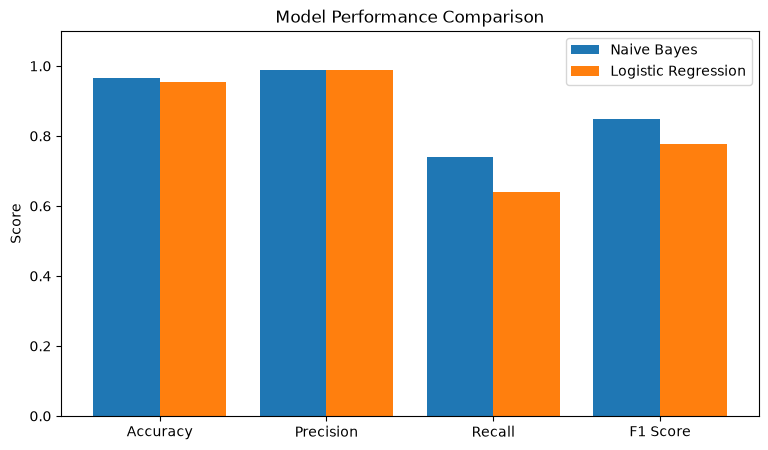

In [55]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

nb_scores = [
    nb_accuracy,
    nb_precision,
    nb_recall,
    nb_f1
]

lr_scores = [
    lr_accuracy,
    lr_precision,
    lr_recall,
    lr_f1
]

x = range(len(metrics))

plt.figure(figsize=(9, 5))

plt.bar(
    [i - 0.2 for i in x],
    nb_scores,
    width=0.4,
    label='Naive Bayes'
)

plt.bar(
    [i + 0.2 for i in x],
    lr_scores,
    width=0.4,
    label='Logistic Regression'
)

plt.xticks(x, metrics)
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.title('Model Performance Comparison')
plt.legend()

plt.show()

Step 14: Create the Confusion Matrix

A confusion matrix shows exactly how many messages were classified correctly and incorrectly.

## Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions made by the classification model.

The four outcomes are:

- **True Negative (TN):** Ham correctly classified as Ham
- **True Positive (TP):** Spam correctly classified as Spam
- **False Positive (FP):** Ham incorrectly classified as Spam
- **False Negative (FN):** Spam incorrectly classified as Ham

False negatives are particularly important in spam detection because they represent spam messages that were missed by the model.

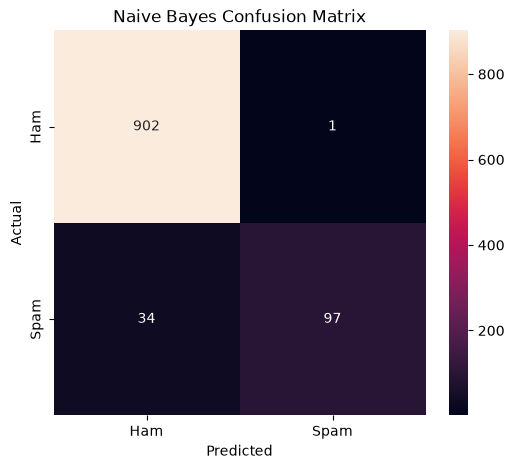

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix')

plt.show()

Step 15: Why Recall Is Important in Spam Detection

## Why is Recall Important in Spam Detection?

Recall measures how many of the actual spam messages were correctly identified by the model.

A **false negative** occurs when a spam message is incorrectly classified as a legitimate (ham) message.

False negatives can be problematic because spam messages may contain:

- Phishing links
- Fraudulent offers
- Malware or malicious content
- Unwanted advertisements

Therefore, a spam detection system should aim for a high recall while also maintaining good precision.

In this project, Multinomial Naive Bayes achieved a spam recall of approximately **74.05%**, which was higher than Logistic Regression's **64.21%**.

This indicates that Naive Bayes was better at identifying actual spam messages on the test dataset.

Step 16: Create WordClouds ☁️

## WordCloud Visualization

WordClouds provide a visual representation of frequently occurring words in the messages.

Separate WordClouds are created for spam and legitimate (ham) messages to identify common language patterns in each category.

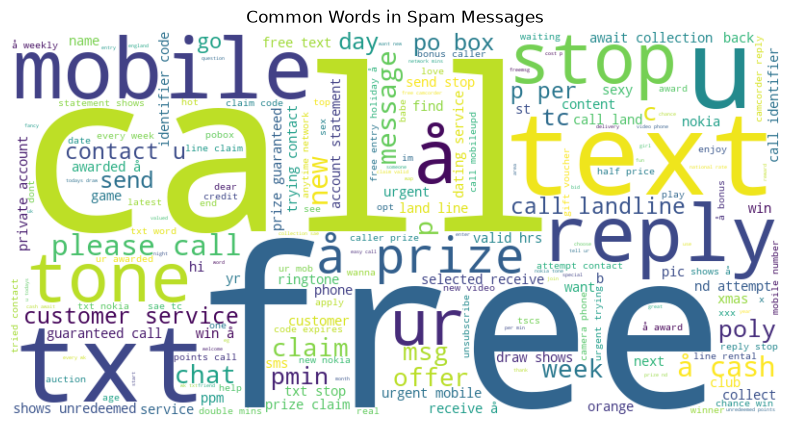

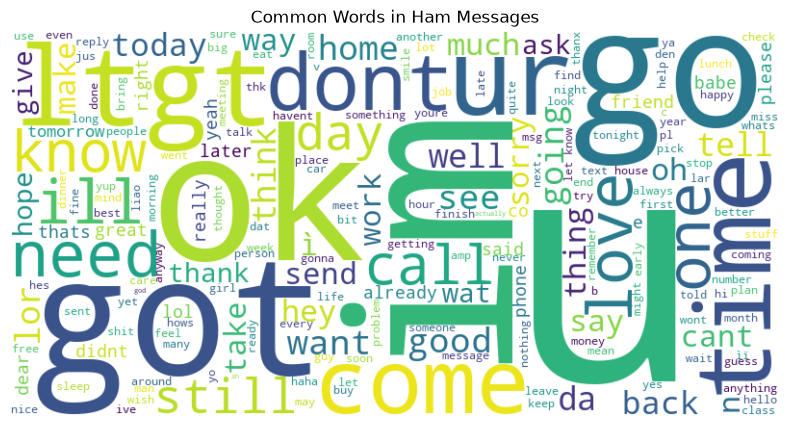

In [57]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Spam messages
spam_text = ' '.join(
    df[df['label'] == 'spam']['clean_message']
)

spam_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_text)

plt.figure(figsize=(10, 5))
plt.imshow(spam_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Spam Messages')
plt.show()


# Ham messages
ham_text = ' '.join(
    df[df['label'] == 'ham']['clean_message']
)

ham_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(ham_text)

plt.figure(figsize=(10, 5))
plt.imshow(ham_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Ham Messages')
plt.show()


Step 17: Test the Model With Your Own Messages

## Testing the Spam Detection Model

The trained Naive Bayes model can also be used to classify new, unseen messages.

The input message is first passed through the same preprocessing and TF-IDF transformation used during training. The model then predicts whether the message is Spam or Ham.

In [72]:
def predict_spam(message):
    cleaned = clean_text(message)
    vectorized = tfidf.transform([cleaned])
    
    prediction = nb_model.predict(vectorized)[0]
    
    if prediction == 1:
        print("Prediction: Spam")
    else:
        print("Prediction: Ham")

In [73]:
predict_spam("Congratulations! You have won a free prize. Click now to claim your reward.")

Prediction: Spam


In [74]:
predict_spam("Hey, are we meeting for lunch today?")

Prediction: Ham
